# Aprendizaje Automático
#### Segundo cuatrimestre 2026

## Regresión Lineal

#### Bibliografía: 
* Pattern Recognition and Machine Learning, Christopher M. Bishop. Capítulo 3.
* The Elements of Statistical Learning, Trevor Hastie, Robert Tibshirani, Jerome Friedman. Capítulo 3.

Papers:
* Ridge Regression: Biased Estimation for Nonorthogonal Problems, Arthur E. Hoerl and Robert W. Kennard, 1970.
* Regression Shrinkage and Selection via the Lasso, Robert Tibshirani, 1996.
* Regularization and variable selection via the elastic net, Hui Zou y Trevor Hastie, 2005.

### Repaso

La regresión lineal es un modelo que asume que la relación entre las variables de entrada $X^T = (X_1, X_2,..., X_p)$ y la variable de salida $Y$ es lineal. Entonces, toma la forma:

$$ f(X) = \beta_0 + \sum_{j=1}^{p} X_j \beta_j$$

En general, se suele escribir de la forma más compacta

$$ f(X) = X^T \beta$$

donde $X$ es un vector de tamaño $p+1$ que contiene un 1 en la primera posición y los valores de las variables de entrada en las siguientes posiciones. $\beta = (\beta_0, \beta_1, ..., \beta_p)$ es el vector de coeficientes a estimar.

### Repaso

El método más común para encontrar los coeficientes es el de **cuadrados mínimos**, que consiste en minimizar la suma de los residuos al cuadrado respecto de $\beta$. Utilizando notación matricial, esto se escribe como:

$$ RSS (\beta) = ||\textbf{y} - \textbf{X} \beta||^2 = (\textbf{y} - \textbf{X} \beta)^T (\textbf{y} - \textbf{X} \beta) $$

y la solución es:

$$ \hat{\beta} = (\textbf{X}^T \textbf{X})^{-1} \textbf{X}^T \textbf{y} $$

De esta forma, las predicciones $\hat{\textbf{y}}$ se obtienen como:

$$\hat{\textbf{y}} = \textbf{X} \hat{\beta} = \textbf{X} (\textbf{X}^T \textbf{X})^{-1} \textbf{X}^T \textbf{y}$$

Desde un punto de vista operativo, ya está. Obtuvimos un estimador de los coeficientes $\hat{\beta}$ que nos sirve para hacer predicciones. No hay, prácticamente, ninguna hipótesis sobre los datos, más allá de que $\textbf{X}$ tiene rango completo.

### Repaso

#### Máxima verosimilitud

Otra forma de estimar los coeficientes es por el método de máxima verosimilitud. En este caso, se asume que los errores son independientes e idénticamente distribuidos (iid) y siguen una distribución normal con media cero y varianza $\sigma^2$. Sin embargo, el estimador que obtenemos es el mismo que el de cuadrados mínimos.

#### SVD

Vimos también que la descomposición en valores singulares (SVD) es una herramienta muy útil para entender la regresión lineal. Si $ X = U D V^T $, $U$ es una matriz de tamaño $N \times p$ con columnas ortonormales, $D$ es una matriz diagonal de tamaño $p \times p$, y $V$ es una matriz ortogonal de tamaño $p \times p$.

Usando SVD, la solución de mínimos cuadrados $ \hat{\beta} = (\textbf{X}^T \textbf{X})^{-1} \textbf{X}^T \textbf{y} $, se puede escribir como:

$$ \hat{\beta} = V D^{-1} U^T y$$

para el caso en el que tenga rango completo. Sino, se puede aproximar por su pseudoinversa, reemplanzando $D^{-1}$ por la matriz diagonal que contiene los inversos de los valores singulares no nulos de $\textbf{X}$.





¿Qué pasa si $\textbf{X}$ no tiene rango completo?¿Qué pasa si hay predictores correlacionados o si hay multicolinealidad?

### Métodos de regularización

Dos formas de motivar los métodos de regularización:
1. **Problemas de multicolinealidad**: Cuando las variables de entrada están altamente correlacionadas, la matriz $\textbf{X}^T \textbf{X}$ es casi singular y su inversa es muy inestable. Esto puede llevar a estimaciones poco confiables de los coeficientes.

1. **Gauss-Markov**: El teorema de Gauss-Markov establece que el estimador de mínimos cuadrados es el mejor estimador lineal insesgado (BLUE). Sin embargo, no garantiza que sea el mejor estimador en términos de varianza. En algunos casos, se pueden encontrar estimadores con menor varianza al introducir un sesgo controlado.

Probablemente veamos Gauss-Markov luego de ver compromiso sesgo-varianza.

### Regresión Ridge

1. **Problemas de multicolinealidad**: Cuando las variables de entrada están altamente correlacionadas, la matriz $\textbf{X}^T \textbf{X}$ es casi singular y su inversa es muy inestable. Esto puede llevar a estimaciones poco confiables de los coeficientes.

Podemos plantear de varias formas el problema de la regresión ridge. Una de las más comunes es la siguiente:

$$ \hat{\beta}^{ridge} = \arg \min_{\beta} \{||\textbf{y} - \textbf{X} \beta||^2 + \lambda ||\beta||^2\} $$

$$ \hat{\beta}^{ridge} = \arg \min_{\beta} \{(\textbf{y} - \textbf{X} \beta)^T (\textbf{y} - \textbf{X} \beta) + \lambda \beta^T \beta\} $$

Sin embargo, hay que tener en cuenta que esta expresión solamente es correcta **si los predictores fueron estandarizados**. De manera más explícita, se puede escribir:

$$ \hat{\beta}^{ridge} = \arg \min_{\beta} \{\sum_{i=1}^{N} (y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j)^2 + \lambda \sum_{j=1}^{p} \beta_j^2\}$$

* ¿Por qué conviene que los atributos estén centrados?
* ¿Por qué conviene que tengan todos la misma varianza?

### Regresión Ridge

¿Qué hace la regularización Ridge?

La regularización Ridge agrega un término de penalización a la función de costo, que es proporcional a la suma de los cuadrados de los coeficientes. Esto tiene el efecto de *achicar* los coeficientes hacia cero.

Entonces $\lambda \ge 0$ es un hiperparámetro que controla la cantidad de regularización. 
* Si $\lambda = 0$, entonces el problema se reduce a la regresión lineal ordinaria. 
* A medida que $\lambda$ aumenta, los coeficientes se vuelven más pequeños y el modelo se vuelve más simple.


### Regresión Ridge

A partir de la notación matricial, el problema de la regresión ridge se puede escribir como:

$$ \hat{\beta}^{ridge} = \arg \min_{\beta} \{(\textbf{y} - \textbf{X} \beta)^T (\textbf{y} - \textbf{X} \beta) + \lambda \beta^T \beta\} $$

En términos de una función de costo, esto se puede escribir como:

$$ RSS(\beta, \lambda) = ||\textbf{y} - \textbf{X} \beta||^2 + \lambda ||\beta||^2 $$

Cuya solución es:

$$ \hat{\beta}^{ridge} = (\textbf{X}^T \textbf{X} + \lambda I)^{-1} \textbf{X}^T \textbf{y} $$

### Regresión Ridge

¿Por qué aborda el problema de la multicolinealidad?

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Única variable predictora

Generamos un dataset sintético, lineal, con una única variable predictora.

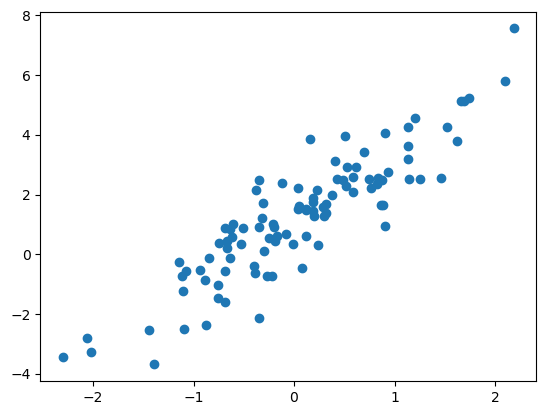

In [2]:
np.random.seed(1)
n = 100

x = np.random.normal(0, 1, n)
slope = 2
intercept = 1
y = slope*x + intercept + np.random.normal(0, 1, n)

plt.scatter(x, y)

In [3]:
def cost_function(slope, intercept, x=x, y=y):
    squared_error = (slope*x + intercept - y)**2
    cost = np.mean(squared_error)
    return cost

In [4]:
%matplotlib qt

/home/esteban/miniconda3/envs/docencia/lib/python3.14/site-packages/mpl_toolkits/mplot3d/proj3d.py:148: RuntimeWarning: invalid value encountered in dot
  vecw = np.dot(M, vec.data)
/home/esteban/miniconda3/envs/docencia/lib/python3.14/site-packages/mpl_toolkits/mplot3d/proj3d.py:150: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0] / w, vecw[1] / w, vecw[2] / w


In [5]:
# Generate a grid of a and b values
a_range = np.linspace(-8, 8, 100)
b_range = np.linspace(-8, 8, 100)
A, B = np.meshgrid(a_range, b_range)
C = np.zeros_like(A)

# Calculate cost for each pair of a and b
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        C[i, j] = cost_function(A[i, j], B[i, j])

# Create the 3D plot of the cost surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A, B, C, cmap='viridis', edgecolor='none')

ax.scatter(slope, intercept, 0, color='r', s=100, label='True Parameters')

ax.set_title('Cost Surface')
ax.set_xlabel('a (slope)')
ax.set_ylabel('b (intercept)')
ax.set_zlabel('Cost')

plt.show()


### Dos variables predictoras

In [6]:
# np.random.seed(1)
n = 100

x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)

beta_1 = 2
beta_2 = 3

### Expected correlation
rho = 0.7

epsilon = np.random.normal(0, 1, n)
x2 = rho * x1 + np.sqrt(1 - rho**2) * epsilon

print(f"Correlación empírica: {np.corrcoef(x1, x2)[0,1]:.3f}")

y = beta_1*x1 + beta_2*x2 + np.random.normal(0, 1, n)

Correlación empírica: 0.703


In [7]:
### scatter plot on 3d

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y, c='b', marker='o')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')

Text(0.5, 0, 'y')

In [8]:
def cost_function(beta, X, y):
    squared_error = (X @ beta - y)**2
    cost = np.mean(squared_error)
    return cost


alpha = 10
def cost_function_with_penalty(beta, X, y, alpha = alpha):
    squared_error = (X @ beta - y)**2
    cost = np.mean(squared_error) + alpha * np.sum(beta**2)
    return cost


# cost_function = cost_function_with_penalty
cost_function = cost_function


In [9]:
X = np.column_stack([x1, x2])
beta = np.array([beta_1, beta_2])

In [10]:
# Generate a grid of a and b values
a_range = np.linspace(-8, 8, 100)
b_range = np.linspace(-8, 8, 100)
A, B = np.meshgrid(a_range, b_range)
C = np.zeros_like(A)

# Calculate cost for each pair of a and b
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        C[i, j] = cost_function(np.array([A[i, j], B[i, j]]), X, y)

# Create the 3D plot of the cost surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A, B, C, cmap='viridis', edgecolor='none')

ax.scatter(beta_1, beta_1, 0, color='r', s=100, label='True Parameters')

ax.set_title('Cost Surface')
ax.set_xlabel('beta_1')
ax.set_ylabel('beta_2')
ax.set_zlabel('Cost')
# ax.axhline(0, c = 'r', lw=4)
# ax.axvline(0, c = 'r', lw=4)

plt.show()


### Estimadores

**Cuadrados mínimos**

In [11]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression(fit_intercept=False).fit(X, y)
print(reg.coef_)
print(reg.intercept_)

[2.0235927  3.13069828]
0.0


**SVD**

In [12]:
U, D, Vh = np.linalg.svd(X, full_matrices=False)
print(D)

beta_svd = Vh.T @ np.diag(1/D) @ U.T @ y
print(beta_svd)


[13.34786046  5.57502342]
[2.0235927  3.13069828]


**Ridge**

$$ \hat{\beta}^{ridge} = (\textbf{X}^T \textbf{X} + \lambda I)^{-1} \textbf{X}^T \textbf{y} $$

In [13]:
alpha = 1
v = np.linalg.inv(X.T @ X + np.eye(X.shape[1]) * alpha)

beta_ridge = v @ X.T @ y
beta_ridge

array([2.02513899, 3.10100153])

### Regresión Ridge

SVD ayuda a entender qué hace la regresión ridge. Si $ \textbf{X} = U D V^T $, entonces $ \hat{\beta}^{ridge} = (\textbf{X}^T \textbf{X} + \lambda I)^{-1} \textbf{X}^T \textbf{y} $ puede reescribirse así:

$$ \hat{\beta}^{ridge} = (V D U^T U D V^T + \lambda I)^{-1} V D U^T \textbf{y} $$
$$ \hat{\beta}^{ridge} = (V D^2 V^T + \lambda I)^{-1} V D U^T \textbf{y} $$
$$ \hat{\beta}^{ridge} = (V (D^2 + \lambda I) V^T)^{-1} V  D U^T \textbf{y} $$

Notar que en $(V (D^2 + \lambda I) V^T)^{-1}$ solamente basta invertir el término del medio, ya que $V$ es ortogonal (hacer la cuenta $V (D^2 + \lambda I)^{-1} V^T V (D^2 + \lambda I) V^T$ para convencerse). Además, es fácil ver que $(D^2 + \lambda I)^{-1}$ es una matriz diagonal, donde los elementos de la diagonal son $1/(d_i^2 + \lambda)$, donde $d_i$ son los valores singulares de $\textbf{X}$. Entonces

$$ \hat{\beta}^{ridge} = V (D^2 + \lambda I)^{-1} V^T V  D U^T \textbf{y} $$


$$ \hat{\beta}^{ridge} = V (D^2 + \lambda I)^{-1} D U^T \textbf{y} $$



### Regresión Ridge

Entonces, por un lado teníamos que 

$$ \hat{\beta}^{ols} = V D^{-1} U^T y$$

y por el otro

$$ \hat{\beta}^{ridge} = V (D^2 + \lambda I)^{-1} D U^T \textbf{y} $$

¡La única diferencia es que en lugar de $D^{-1}$ tenemos $(D^2 + \lambda I)^{-1} D$! Ambas son matrices diagonales, en el primer caso cada elemento es $1/d_i$, y en el segundo caso es $d_i/(d_i^2 + \lambda)$. 

Comparemos $1/d_i$ y $d_i/(d_i^2 + \lambda)$:
* Tanto $d_i$ como $\lambda$ son no negativos, por lo que:


$$  (\frac{d_i}{d_i^2 + \lambda}) /  \frac{1}{d_i} = \frac{d_i^2}{d_i^2 + \lambda} \leq 1$$

¿Qué implica?

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
d_i = np.linspace(0.0, 10, 1000)
alpha = 1

plt.plot(d_i, 1/d_i, label = 'OLS')
plt.plot(d_i, d_i/(d_i**2 + alpha), label = 'Ridge')

plt.ylim(0,2)
plt.legend()
plt.show()

/tmp/ipykernel_42508/3813317631.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.plot(d_i, 1/d_i, label = 'OLS')


### Regresión Ridge

¿Qué implica?

Se parece a recortar los valores singulares, pero de manera más suave. 

### Ejercicios

**Ejercicio - Investigar:** ¿Qué es *subset selection*?

**Ejercicio:** Utilizando el dataset de *Prostate Cancer*:
1. Implementar un estimador de Ridge. Comparar con los resultados de la Tabla 3.3 del libro Elements of Statistical Learning. ¿Qué nivel de regularización se utilizó?¿Cómo decidirías el nivel de regularización?

**Ejercicio:** Una de las características de Ridge es que "reparte el peso" entre atributos correlacionados. Veámoslo en el caso extremo: supongamos que tenemos dos atributos idénticos, $x_2 = x_1$.

Mostrar que el término de error $|\textbf{y}-\textbf{X}\beta|^2$ depende de $\beta_1$ y $\beta_2$ solo a través de su suma $\beta_1+\beta_2$. ¿Qué implica esto sobre la unicidad de la solución de cuadrados mínimos?
Fijada esa suma en un valor $c$, minimizar el término de penalización $\beta_1^2+\beta_2^2$ sujeto a $\beta_1+\beta_2=c$. ¿Cuál es el reparto óptimo?


